In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# plt.rcParams['font.family'] = 'Malgun Gothic' # For Windows
plt.rcParams["font.family"] = "AppleGothic"   # Mac
%matplotlib inline

In [42]:
df=pd.read_csv("../공유/final_cleaned_airbnb.csv")

In [43]:
df.shape

(19861, 60)

In [44]:
# 점유율 = 숙박일수 / 365
df['occupancy_rate'] = df['estimated_occupancy_l365d'] / 365

In [45]:
# 연매출 = 1박 가격 * 숙박일수
df['calc_revenue'] = df['price'] * df['estimated_occupancy_l365d']

In [46]:
df.groupby(
['neighbourhood_group_cleansed','room_type']
)['calc_revenue'].median()

neighbourhood_group_cleansed  room_type      
Bronx                         Entire home/apt       0.0
                              Private room          0.0
Brooklyn                      Entire home/apt       0.0
                              Hotel room            0.0
                              Private room          0.0
Manhattan                     Entire home/apt       0.0
                              Hotel room            0.0
                              Private room          0.0
Queens                        Entire home/apt       0.0
                              Hotel room         1488.5
                              Private room          0.0
Staten Island                 Entire home/apt    4920.0
                              Private room          0.0
Name: calc_revenue, dtype: float64

In [47]:
# 연매출과 점유율이 58%정도가 0
(df['occupancy_rate'] == 0).mean()

np.float64(0.5872816071698304)

연매출 , 점유율이 58%가 0인 값이 많아서 이런 결과 값이 나옴.
근데 퀸즈와 아일랜드에는 값이 찍힘.
여기서. 만약 운영되지 않은 숙소가 많아서 0이 찍히는 거라면???

목표는 가격전략을 할수도 있고, 또 페르소나 (호스트들에게 투자금에 따라 블루오션에서 어디 레드오션에서 어디를 추천) => 을 할거라면 실제 운영중인 +실제 매출 을 봐야하지 않을까?
 그렇다면 운영중이지 않은(실제매출을 설명할수 없음과 0의 비율이 50%이상으로 문자열 상관분석에 영향을 준다면??))
 1. 운영중이지 않은 숙소가 brox,brooklyn, manhattan이 가장 많은 때, 우리는 지금 값이 찍히는 Q지역과 iland 지역을 추천 할 수 있을까? 실제 매출과 비교를 했나? 즉. 실제 운영중인 숙소들에 대한 실제 매출 데이터냐???
 -> 확인해보기
 
 비운영 -> 추정 연매출이 0이다.
 향후 365예약이 0이다. -> 비활성 또는 오랫동안 일 안함


In [50]:
df.groupby(['neighbourhood_group_cleansed','room_type']).agg(
    total_listing=('price','count'),
    zero_revenue=('estimated_revenue_l365d', lambda x: (x==0).sum())
)

total_listing  zero_revenue
neighbourhood_group_cleansed room_type                                   
Bronx                        Entire home/apt            299           186
                             Private room               515           295
Brooklyn                     Entire home/apt           3177          1797
                             Hotel room                  16            13
                             Private room              3392          1919
Manhattan                    Entire home/apt           6035          3844
                             Hotel room                 336           267
                             Private room              2754          1518
Queens                       Entire home/apt           1152           666
                             Hotel room                   8             4
                             Private room              1894          1016
Staten Island                Entire home/apt            134            61
                             Private room               149            78

<Axes: xlabel='neighbourhood_group_cleansed,room_type'>

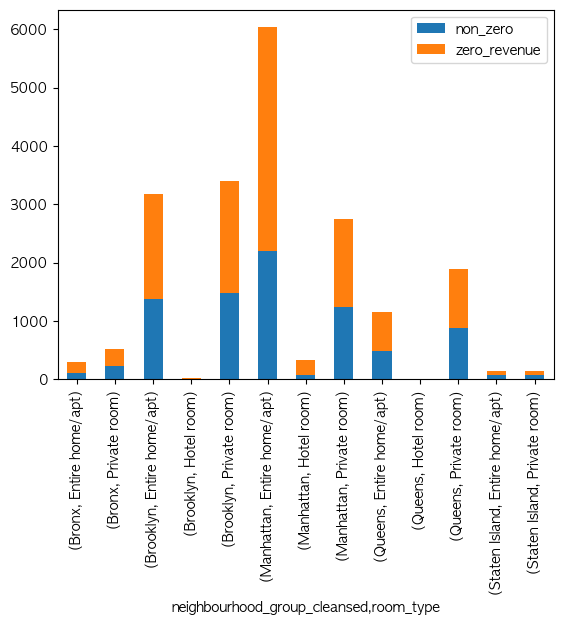

In [51]:
pivot_df = df.groupby(['neighbourhood_group_cleansed','room_type']).agg(
    total_listing=('price','count'),
    zero_revenue=('estimated_revenue_l365d', lambda x: (x==0).sum())
).reset_index()

pivot_df['non_zero'] = pivot_df['total_listing'] - pivot_df['zero_revenue']

pivot_df.set_index(['neighbourhood_group_cleansed','room_type'])[['non_zero','zero_revenue']].plot(
    kind='bar',
    stacked=True
)

In [10]:
df.groupby('neighbourhood_group_cleansed').agg(
    total_listing=('price', 'count'),
    zero_revenue=('estimated_revenue_l365d', lambda x: (x==0).sum()),
    zero_availability=('availability_365', lambda x: (x==0).sum())
).reset_index()

,neighbourhood_group_cleansed,total_listing,zero_revenue,zero_availability
0,Bronx,814,481,12
1,Brooklyn,6585,3729,23
2,Manhattan,9125,5629,101
3,Queens,3054,1686,17
4,Staten Island,283,139,1


In [11]:
len(df[df['estimated_revenue_l365d']==0])

11664

In [12]:
len(df[df['availability_365']==0])

154

In [13]:
# 운영 안하는 숙소 확인하기 => 위의 zero_revenue의 합산과 아래의 합산 값이 같음.
df[df['estimated_revenue_l365d']==0][
['availability_365','estimated_occupancy_l365d']
].describe()

,availability_365,estimated_occupancy_l365d
count,11664.000000,11664.0
mean,256.822102,0.0
std,112.823431,0.0
min,0.000000,0.0
25%,178.000000,0.0
50%,285.000000,0.0
75%,364.000000,0.0
max,365.000000,0.0


전체 데이터 중 약 58%가 매출 0으로 나타났으며 이는 실제 운영되지 않는 숙소 또는 예약이 발생하지 않은 숙소일 가능성이 있다. 이러한 데이터는 매출 예측 모델의 왜곡을 초래할 수 있으므로 매출이 발생한 숙소만을 대상으로 회귀 분석을 진행하였다.
따라 수치형 변수와의 상관관계 분석과 문자열 변수와의 상관관계 분석을 운영되지 않는 숙소를 제거한 동일한 데이터로 분석을 한다.
매출예측 모델 왜곡 방지를 위해 제거 >>>
분석 기준이 서로 다른것을 방지하기 위한>> 해석의 일관성


In [14]:
df_active = df[df['estimated_revenue_l365d'] > 0]
df_active['estimated_revenue_l365d'].describe()
np.log1p(df_active['estimated_revenue_l365d'])

3         9.904537
5         9.757363
7         9.746015
13       10.146473
14       10.427654
           ...    
18990     7.478170
19033     9.387733
19042     8.221748
19141     7.965893
19163     8.037543
Name: estimated_revenue_l365d, Length: 8197, dtype: float64

In [15]:
df_active[['price','occupancy_rate','calc_revenue']].corr()

,price,occupancy_rate,calc_revenue
price,1.000000,-0.111887,0.579207
occupancy_rate,-0.111887,1.000000,0.534088
calc_revenue,0.579207,0.534088,1.000000


<<<<<<<<    전체 숙소 포함한 상관관계 분석   >>>>>>>>
가격과 점유율 = 음의 상관관계 -0.10           = 가격과 점유율은 매우 약한 상관관계가 보인다. 따라 가격이 점유율에 큰 영향을 미친다고 볼 수 없다.
가격과 연매출 = 양의 상관관계 그러나, 0.017    = 거의 0 , 즉 가격과 매출은 상관관계가 없다. (가격만으로 연매출을 설명할 수 없음.)
점유율과 연매출 = 양의 상관관계 0.75          = 점유율이 높아질수록 연매출이 올라간다.

 저가숙소 + 높은 점유율을 띄므로 고가숙소보다 매출이 높을 수도 있다. 따라. 가격과 연매출이 상관관계가 없게 나왔다. 

결론: 매출은 가격보다 점유율이 더 중요하다.
매출을 잘 설명할 수 있는 강한 변수 : 점유율과 연매출 = 양의 상관관계 0.75

<<<<<<<<    운영되지않는 숙소를 제거한 운영중인 숙소에 관하여 상관관계 분석   >>>>>>>>
가격과 점유율 = 음의 상관관계 -0.11           = 가격과 점유율은 매우 약한 상관관계가 보인다. 따라 가격이 점유율에 큰 영향을 미친다고 볼 수 없다.
가격과 연매출 = 양의 상관관계 0.57    = 가격과 연매출의 상관관계가 강함.
점유율과 연매출 = 양의 상관관계 0.53         = 점유율이 높아질수록 연매출이 올라간다.


결론: 매출은 가격과 점유율이 둘다 중요하다. 그러나 가격과 점유율의 상관관계는 약함..
매출을 잘 설명할 수 있는 강한 변수 : 점유율과 가격 = 양의 상관관계 0.57 /0.57

전체숙소 와 운영중인숙소 데이터의 차이점.

 전체 숙소 데이터와 비교했을 때,
운영중 숙소 데이터에서는 가격과 점유율 간 관계가 더 뚜렷하게 나타났다.
이는 예약이 없는 비활성 숙소들이 제거되면서
실제 시장 경쟁 구조가 더 잘 반영되었기 때문으로 볼 수 있다.

따라서 매출을 설명하기 위해서는
가격이나 점유율 자체보다
점유율을 결정하는 요인을 분석하는 것이 더 중요하다.

In [16]:
df[['estimated_occupancy_l365d','occupancy_rate']].head(20)

,estimated_occupancy_l365d,occupancy_rate
0,0,0.000000
1,0,0.000000
2,0,0.000000
3,154,0.421918
4,0,0.000000
5,180,0.493151
6,0,0.000000
7,255,0.698630
8,0,0.000000
9,0,0.000000


In [17]:
df_active[['price','occupancy_rate','number_of_reviews','reviews_per_month','number_of_reviews_ltm','calc_revenue']].corr()

,price,occupancy_rate,number_of_reviews,reviews_per_month,number_of_reviews_ltm,calc_revenue
price,1.000000,-0.111887,-0.043012,-0.017564,-0.017989,0.579207
occupancy_rate,-0.111887,1.000000,0.308243,0.358222,0.407415,0.534088
number_of_reviews,-0.043012,0.308243,1.000000,0.603894,0.471084,0.153416
reviews_per_month,-0.017564,0.358222,0.603894,1.000000,0.890655,0.219018
number_of_reviews_ltm,-0.017989,0.407415,0.471084,0.890655,1.000000,0.234191
calc_revenue,0.579207,0.534088,0.153416,0.219018,0.234191,1.000000


<<<<   전체숙소 (비운영 숙소 포함 ) >>>>
가격 과 외 : 음의 상관 = 가격 변수와 점유율,리뷰수,월평균 리뷰수와 큰 관계가 없음.
점유율과 매출 상관 관계 있음.
리뷰수와 점유율 : 0.35 양의 상관계수 = 리뷰수와 점유율 약한 상관관계 있음 (리뷰수가 많은 숙소는 점유율이 높은 경향이있음)
월평균리뷰 수 와 점유율 : 0.44 양의 상관계수 = 월평균 리뷰수와 점유율 중간 정도 상관관계 있음.(리뷰활동이 많은 숙소일 수록 점유율이 높음)
리뷰와 월평균 리뷰수 :  0.65 양의 상관 = 리뷰활동이 활발한 숙소가 리뷰 (리뷰수가 많은 숙소는 리뷰활동도 활발함.)

결론 가격보다 리뷰가 점유율에 더 중요하다.
매출을 잘 설명할 수 있는 강한 변수 : 최근 12개월 리뷰 수와 연매출 = 양의 상관관계 0.458

<<<<   운영 중인 숙소만 >>>>
리뷰 수 0.15/0.21/0.23 리뷰수와 연매출 상관관계가 강하다 말할수없음. 아주약간 관계 있다 정도(의미없음)

In [18]:
df_active.groupby(
['neighbourhood_group_cleansed']
)['calc_revenue'].median()

neighbourhood_group_cleansed
Bronx             9120.0
Brooklyn         17160.0
Manhattan        17400.0
Queens           14160.0
Staten Island    10920.0
Name: calc_revenue, dtype: float64

<Axes: xlabel='occupancy_rate', ylabel='calc_revenue'>

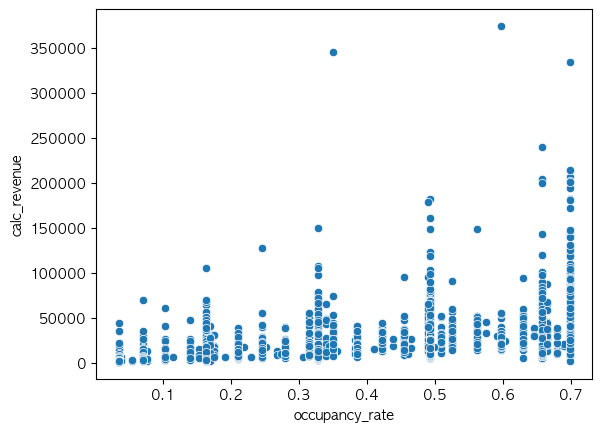

In [19]:
sns.scatterplot(
    x='occupancy_rate',
    y='calc_revenue',
    data=df_active
)

<Axes: xlabel='room_type', ylabel='calc_revenue'>

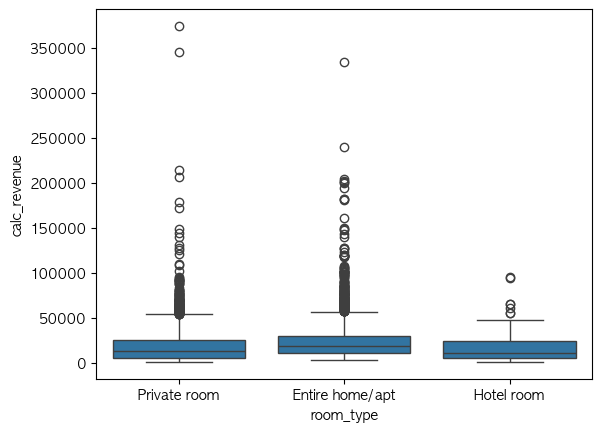

In [20]:
sns.boxplot(
    x='room_type',
    y='calc_revenue',
    data=df_active
)

estimated_revenue_l365d (최근 일년 기준 추정매출)
price (1박 숙소가격)
occupancy_rate (점유율)
room_type (Entire home/apt / Private room,Hotel room)
neighbourhood_group_cleansed (자치구별) 5개
number_of_reviews_ltm (최근 12개월 리뷰수)

Revenue = b0 + b1(price)+ b2(occupancy_rate)+ b3(room_type)+ b4(neighbourhood_group_cleansed)+ b5(number_of_reviews_ltm)


In [37]:
# amenities_len 컬럼 생성
df_active['amenities_len'] = df_active['amenities'].apply(lambda x: len(x.split(',')) if pd.notnull(x) else 0)

# 확인
df_active[['amenities','amenities_len']].head()

,amenities,amenities_len
3,"[""Oven"", ""Rice maker"", ""Laundromat nearby"", ""L...",29
5,"[""Oven"", ""Fire extinguisher"", ""Extra pillows a...",26
7,"[""Fire extinguisher"", ""Extra pillows and blank...",25
13,"[""Baking sheet"", ""Oven"", ""Dedicated workspace""...",44
14,"[""Garden view"", ""Dedicated workspace"", ""Extra ...",27


점유율과 변수들 간의 상관계수
occupancy_rate       1.000000
number_of_reviews    0.308243
amenities_len        0.164939
price               -0.111887
Name: occupancy_rate, dtype: float64


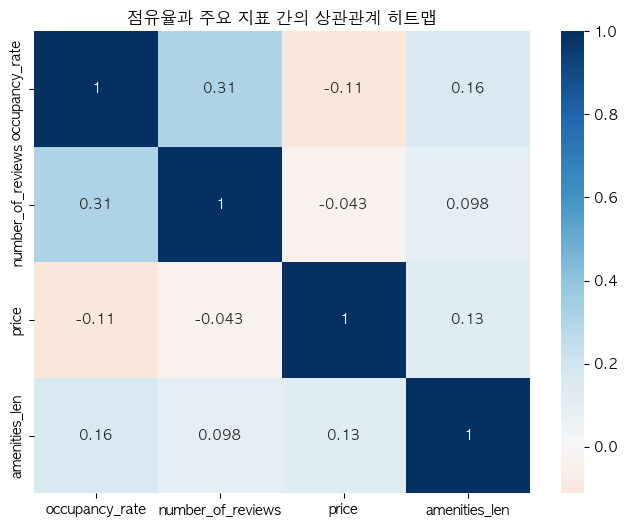

In [39]:
#수치형 데이터들만 모아서 점유율과의 상관계수 계산
cols = ['occupancy_rate', 'number_of_reviews', 'price', 'amenities_len' ]
correlation_matrix = df_active[cols].corr()

# 점유율(occupancy_rate) 기준 정렬해서 보기
print("점유율과 변수들 간의 상관계수")
print(correlation_matrix['occupancy_rate'].sort_values(ascending=False))

#히트맵으로 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', center=0)
plt.title('점유율과 주요 지표 간의 상관관계 히트맵')
plt.show()

In [22]:
df_active['amenities_len']

3        29
5        26
7        25
13       44
14       27
         ..
18990    26
19033    10
19042    17
19141    26
19163    38
Name: amenities_len, Length: 8197, dtype: int64

In [29]:
df_active[['price','occupancy_rate','amenities_len','calc_revenue']].corr()

,price,occupancy_rate,amenities_len,calc_revenue
price,1.000000,-0.111887,0.125621,0.579207
occupancy_rate,-0.111887,1.000000,0.164939,0.534088
amenities_len,0.125621,0.164939,1.000000,0.219734
calc_revenue,0.579207,0.534088,0.219734,1.000000


가격과 어메니티 :  -0.08 상관계수 차이가 거의 없다.
어메니티와 연매출:  0.25  , 상관계수 차이가 약간 있다.
어매니티수와 점유율 : 0.38 , 상관계수 차이가 약간 더 있다.

In [25]:
import statsmodels.formula.api as smf

model = smf.ols(
"estimated_revenue_l365d ~ price + occupancy_rate + amenities_len + C(room_type) + C(neighbourhood_group_cleansed)+ C(property_regulation_type)",
data=df_active
).fit()

print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     estimated_revenue_l365d   R-squared:                       0.711
Model:                                 OLS   Adj. R-squared:                  0.711
Method:                      Least Squares   F-statistic:                     1831.
Date:                     Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                             14:27:10   Log-Likelihood:                -87527.
No. Observations:                     8197   AIC:                         1.751e+05
Df Residuals:                         8185   BIC:                         1.752e+05
Df Model:                               11                                         
Covariance Type:                 nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

C(neighbourhood_group_cleansed)[T.Brooklyn]            2592.3594    381.182      6.801      0.000    1845.210    3339.508
C(neighbourhood_group_cleansed)[T.Manhattan]           2870.9427    380.698      7.541      0.000    2124.744    3617.142
C(neighbourhood_group_cleansed)[T.Queens]              1024.6324    404.282      2.534      0.011     232.207    1817.058
C(neighbourhood_group_cleansed)[T.Staten Island]        673.6817    707.262      0.953      0.341    -712.610    2059.974

모델 전체 정보

종속변수: 연간 추정 매출 (estimated_revenue_l365d)

관찰치 수: 19,861개

설명력: R² = 0.604 → 독립변수들이 연매출 변동의 약 60.4% 설명

모델 유의성: F-statistic = 2,753, p < 0.001 → 모델 전체 통계적으로 유의

Condition No. = 6,460 → 다중공선성 가능성 존재 (더미 변수 간 상관 주의)

주요 변수별 해석
| 변수                      | 계수 (coef)                                                            | p-value                     | 해석                                                   |       |                               |
| ----------------------- | -------------------------------------------------------------------- | --------------------------- | ---------------------------------------------------- | ----- | ----------------------------- |
| **Intercept**           | 5,011                                                                | 0.000                       | 기준 그룹(Entire home, 기본 지역, 규제 없음) 기준 연매출              |       |                               |
| **Room Type**           |                                                                      |                             | Hotel room: -8,762, Private room: -2,836             | 0.000 | 기준(Entire home/apt) 대비 연매출 감소 |
| **Neighbourhood**       | Brooklyn +2,782, Manhattan +3,313, Queens +1,206, Staten Island +726 | p<0.01 except Staten Island | 기준지역 대비 연매출 증감, Staten Island는 통계적 유의X               |       |                               |
| **Property Regulation** | Long-term -8,977, Short-term -9,541                                  | 0.000                       | 규제가 있는 경우 연매출 감소                                     |       |                               |
| **Price**               | 2.38                                                                 | 0.000                       | 가격 1달러 증가 시 연매출 약 +2.38 증가                           |       |                               |
| **Occupancy Rate**      | 49,940                                                               | 0.000                       | 점유율 1% 증가 시 연매출 약 49,940 증가 → 가장 큰 영향력               |       |                               |
| **Amenities Length**    | 66.36                                                                | 0.000                       | 어메니티 1개 증가 시 연매출 약 66달러 증가 → 통계적 유의하지만 영향력은 점유율보다 작음 |       |                               |


“연매출은 점유율이 가장 큰 영향을 주고, 숙소 유형과 위치, 규제 여부가 중간 수준의 영향을 미치며, 가격과 어메니티는 작지만 통계적으로 유의미한 추가 효과를 제공한다.”

상관계수에서는 점유율과 매출의 상관계수가 높고, 어매니티같은 변수도 점유율과 상관계수가 유의미 한 결과를 보았다면,
어매니티같은 변수가 점유율에 대해 미치는 효과는 어느정도인가? 에 대한 회귀분석.

In [27]:
import statsmodels.formula.api as smf

model = smf.ols(
"occupancy_rate ~ price + amenities_len + C(room_type) + C(neighbourhood_group_cleansed)+ C(property_regulation_type)",
data=df_active
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         occupancy_rate   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     192.3
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:27:54   Log-Likelihood:                 1631.5
No. Observations:                8197   AIC:                            -3241.
Df Residuals:                    8186   BIC:                            -3164.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

간접효과(Indirect effect)

=
(
어메니티 → 점유율 계수
)
×
(
점유율 → 연매출 계수
)
간접효과=(어메니티 → 점유율 계수)×(점유율 → 연매출 계수)

총효과(Total effect)

=
직접효과
+
간접효과
총효과=직접효과+간접효과

| 경로                          | 계수     | 계산             | 효과                         |
| --------------------------- | ------ | -------------- | -------------------------- |
| 어메니티 → 점유율                  | 0.003  | -              | 점유율 1 증가 → 0.3%p 상승        |
| 점유율 → 연매출                   | 49,940 | -              | 점유율 1%p 증가 → 연매출 +49,940달러 |
| **간접효과 (어메니티 → 점유율 → 연매출)** | -      | 0.003 × 49,940 | **≈150달러**                 |
| 어메니티 → 연매출 (직접)             | 66     | -              | 1개 추가 → +66달러              |
| **총효과**                     | -      | 66 + 150       | **≈216달러**                 |


해석: 어메니티 1개 추가 →

점유율 경로로 간접 효과 약 150달러

직접 효과 약 66달러

총 연매출 증가 약 216달러
-------------------------
결론 및 전략적 의미

어메니티가 연매출에 미치는 총 효과는 직접 + 간접

간접효과가 직접효과보다 큼 → 점유율 증대를 통해 연매출을 크게 올릴 수 있는 전략 수단임

숙소 유형, 지역, 가격 등 다른 변수와 결합하면 더 정밀한 전략 수립 가능

------------------------------------
가격도 점유율에 얼마나 미치느냐
결론만
* 가격을 1달러 올리면 직접적으로는 연매출 2.38달러 증가
* 하지만 점유율이 약간 떨어져서 간접효과로 연매출 3.3달러 감소
* 총효과 = 약 -0.91달러 → 가격 인상은 실제로는 미세하게 연매출 감소 가능
---------------------------------------------------------------
#결론
| 변수        | 직접효과 (Direct) | 점유율 경로 간접효과 (Indirect) | 총효과 (Total) |
| --------- | ------------- | ---------------------- | ----------- |
| 어메니티 (1개) | 66            | 150                    | 216         |
| 가격 (1달러)  | 2.38          | -3.29                  | -0.91       |


최종 전략적 의미:
“연매출은 점유율이 가장 큰 영향을 주고, 숙소 유형과 위치, 규제 여부가 중간 수준의 영향을 미치며, 가격과 어메니티는 작지만 통계적으로 유의미한 추가 효과를 제공한다.”


어메니티 → 점유율 증가 → 연매출 증가 → “투자 가치 높음”

가격 → 약간의 직접 증가 있지만 점유율 감소로 간접 영향이 더 큼 → 가격 인상은 신중하게